In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MaxNLocator, MultipleLocator

import warnings
warnings.filterwarnings('ignore')

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

In [17]:
# proj_path = "/home/4cv/project/gc_openPMD-viewer/"
proj_path = "/data/gc_openPMD-viewer/"

df_path = proj_path + "results/final/small_mem.csv"
df = pd.read_csv(df_path, header=[0])

In [18]:
def process_df(df, lower_bound, upper_bound, target_percentage=None):
    print("Before Sampling, each group size:")
    print(df.groupby(['target_percentage', 'select_set']).size() / 7)

    number_of_each_group = 10
    if target_percentage:
        # Filter DataFrame by target_percentage
        df_filtered = df[df['target_percentage'] == target_percentage]
    else:
        df_filtered = df

    # Group by select_set and get unique envelope values for each group
    unique_envelopes = df_filtered.groupby('select_set')['envelope'].unique().reset_index()

    # Rename columns for clarity
    unique_envelopes.columns = ['select_set', 'unique_envelopes']

    # print the number of unique envelopes for each group
    # for i in range(number_of_each_group):
    #     print(f"Group {i+1} has {len(unique_envelopes['unique_envelopes'][i])} unique envelopes.")

    # Function to sample envelopes
    # def sample_envelopes(envelopes, n):
    #     return list(envelopes.sample(n=min(n, len(envelopes))))

    # Apply the sampling to each group
    # unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes'].apply(lambda x: list(pd.Series(x).sample(number_of_each_group)))
    # # unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes'].apply(lambda x: sample_envelopes(pd.Series(x), number_of_each_group))
    #
    # # Clean up the DataFrame by dropping the original unique envelopes column
    # for i in range(number_of_each_group):
    #     print(f"Group {i+1} has {len(unique_envelopes['sampled_envelopes'][i])} sampled envelopes.")

    unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes']

    # Explode the sampled_envelopes into separate rows
    exploded_unique_envelopes = unique_envelopes.explode('sampled_envelopes')

    # Merge the exploded_unique_envelopes back to df_filtered to keep only relevant rows
    filtered_df = df_filtered.merge(exploded_unique_envelopes[['select_set', 'sampled_envelopes']],
                                    left_on=['select_set', 'envelope'],
                                    right_on=['select_set', 'sampled_envelopes'])

    # Drop the 'sampled_envelopes' column as it's now redundant
    filtered_df = filtered_df.drop(columns='sampled_envelopes')

    print("")
    print(filtered_df.groupby(['target_percentage', 'select_set']).size() / 7)

    filtered_df = filtered_df[['select_set', 'test_type', 'query_index_time_elapsed', 'remove_duplication_time_elapsed',
                               'sort_block_metadata_time_elapsed', 'find_optimal_read_solution_time_elapsed',
                               'get_target_data_time_elapsed', 'get_support_data_time_elapsed',
                               'data_calculation_time_elapsed', 'data_apply_select_time_elapsed', 'apply_particle_level_select_array_time_elapsed', 'total_time_elapsed', 'query_result_size', 'chunk_range_size', 'total_memory_used', 'data_size']]

    filtered_df['indexing'] = filtered_df['query_index_time_elapsed'] + df['remove_duplication_time_elapsed'] + df['sort_block_metadata_time_elapsed'] + df['find_optimal_read_solution_time_elapsed']
    filtered_df['IO_time'] = filtered_df['get_target_data_time_elapsed'] + df['get_support_data_time_elapsed']
    filtered_df['calculation'] = filtered_df['data_calculation_time_elapsed'] + df['data_apply_select_time_elapsed'] + df['apply_particle_level_select_array_time_elapsed']

    filtered_df = filtered_df[['select_set', 'test_type', 'indexing', 'IO_time', 'calculation', 'total_time_elapsed', 'query_result_size', 'chunk_range_size', 'total_memory_used', 'data_size']]

    filtered_df = filtered_df[filtered_df['data_size'] <= upper_bound]
    filtered_df = filtered_df[filtered_df['data_size'] >= lower_bound]

    # Group by select_set and test_type, then compute the average value
    averaged_df = filtered_df.groupby(['select_set', 'test_type']).mean().reset_index()


    # only keep the select_set with specific values: ('ux',),  ('ux','uy'),  ('ux','uy','uz'),  ('ux','uy','uz','x'), ('ux','uy','uz','x','y'), ('ux','uy','uz','x','y','z')
    averaged_df = averaged_df[averaged_df['select_set'].isin(["('ux',)", "('ux','uy')", "('ux','uy','uz')", "('ux','uy','uz','x')", "('ux','uy','uz','x','y')", "('ux','uy','uz','x','y','z')"])]

    # a new column to indicate the length of select_set
    averaged_df['select_set_length'] = averaged_df['select_set'].apply(lambda x: len(eval(x)))
    averaged_df['plot_from_0'] = averaged_df['select_set_length'].apply(lambda x: x - 1)

    # sort by select_set_length
    averaged_df = averaged_df.sort_values('select_set_length')

    averaged_df['direct_io_number'] = averaged_df['select_set_length'] * averaged_df['query_result_size']
    averaged_df['grouping_io_number'] = averaged_df['select_set_length'] * averaged_df['chunk_range_size']
    return averaged_df


In [19]:
# Define a formatter function for y-axis labels
def exp_formatter(y, pos):
    if y == 0:
        return r"0"
    return r"$\mathregular{{10}}^{{\mathregular{{{}}}}}$".format(int(y))

In [20]:
global_tick_fontsize = 20
global_label_fontsize = 24
global_annotation_fontsize = 18
global_legend_fontsize = 18

In [21]:
averaged_df = process_df(df, 3000, 5000)

Before Sampling, each group size:
target_percentage  select_set                  
0.01%              ('ux','uy')                     21.428571
                   ('ux','uy','uz')                21.428571
                   ('ux','uy','uz','x')            21.428571
                   ('ux','uy','uz','x','y')        21.428571
                   ('ux','uy','uz','x','y','z')    21.428571
                   ('ux','uy','x','y')             21.428571
                   ('ux',)                         21.428571
                   ('x','y')                       21.428571
                   ('x','y','z')                   21.428571
                   ('x',)                          21.428571
0.10%              ('ux','uy')                     21.428571
                   ('ux','uy','uz')                21.428571
                   ('ux','uy','uz','x')            21.428571
                   ('ux','uy','uz','x','y')        21.428571
                   ('ux','uy','uz','x','y','z')    21.428571
   

[3000. 3500. 4000. 4500. 5000.]
[-1.  0.  1.  2.  3.  4.]


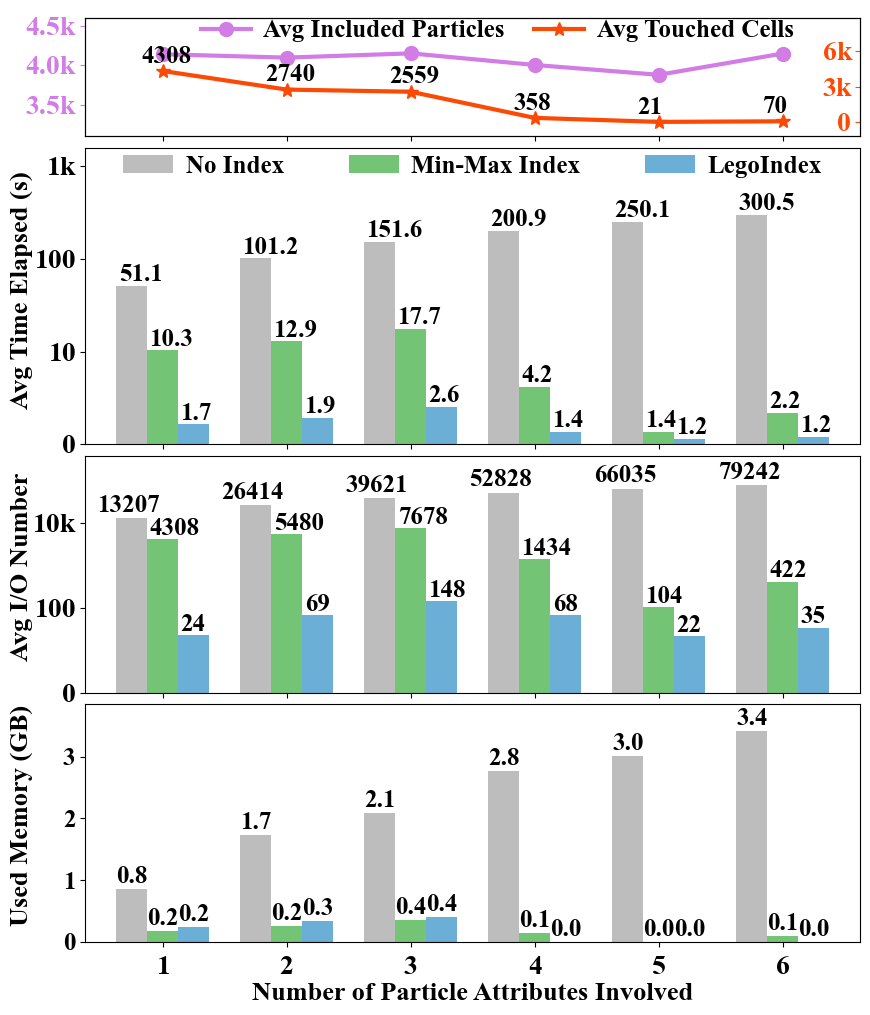

In [22]:
# only keep the test_type with specific values: 1 and 25\
plot_df = averaged_df[averaged_df['test_type'].isin([1, 2, 25])]

#

row_ratios = [2, 5, 4, 4]

# fig, ax = plt.subplots()
# set figure size
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 12), gridspec_kw={'height_ratios': row_ratios})

''' subplot 1 '''
ax = axes[0]
plot_df[averaged_df['test_type'] == 25].pivot(index='plot_from_0', columns='test_type', values='data_size').plot(kind='line', ax=ax, color='#d27ce6', marker='o', markersize=10, linewidth=3)
plt.xticks(rotation=0)
ax.set_ylim(3100, 4600)

# ax.yaxis.set_major_locator(MultipleLocator(1e4))
current_values = ax.get_yticks()
print(current_values)

ax.set_yticklabels([f"{round(y / 1000, 1)}k" if y != 0 else "0" for y in current_values])
# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#d27ce6')  # Adjust label size as needed

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Remove the legend
# ax.get_legend().remove()
legend = ax.legend(title='', loc='upper left', labels=['Avg Included Particles'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.12, 1.17), columnspacing=2.6, handletextpad=0.5)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))

# ax2.yaxis.set_tick_params(direction='in')  # Move ticks inside
ax2.yaxis.set_tick_params(direction='in', pad=-27)  # Move ticks inside
# ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()


plot_df[plot_df['test_type'] == 25].pivot(index='plot_from_0', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='#fc4903', marker='*', markersize=10, linewidth=3)

# Annotate each data point
for i, (x, y) in enumerate(zip(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata())):
    ax2.annotate(
        str(round(y)),  # Text label
        (x - 0.17, y + 700),  # Position (adjust y + 200 for visibility)
        fontsize=global_annotation_fontsize,
        fontweight='bold'
    )


# ax.set_autoscale_on(False)
ax2.set_ylim(-1200, 8800)

# y label
# ax.set_ylabel("Avg Touched Cells", fontsize=global_label_fontsize - 5, labelpad=25, fontweight='bold')
ax2.yaxis.set_label_coords(-0.068, 0.5)

ax2.yaxis.set_major_locator(MultipleLocator(3000))
current_values = ax2.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# ax2.set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in current_values])
y_ticks = ["-1", "  0", "3k", "6k"]
ax2.set_yticklabels(y_ticks)
ax2.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#fc4903')  # Adjust label size as needed


for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

legend = ax2.legend(title='', loc='upper left', labels=['Avg Touched Cells'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.55, 1.17), columnspacing=2.6, handletextpad=0.5)
for text in legend.get_texts():
    text.set_fontweight('bold')


''' subplot 2 '''
# the value difference between test_type 1 and 25 is too large, so we use log scale
plot_df['total_time_elapsed'] = plot_df['total_time_elapsed'].apply(lambda x: np.log10(x+1))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

ax = axes[1]
# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
plt.xticks(rotation=0)
legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0.02, 1.05), columnspacing=2.6, handletextpad=0.5)
# legend = ax.legend(title='', loc='upper left', labels=['OpenPMD-viewer', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0, 1.13), columnspacing=0.8)

for text in legend.get_texts():
    text.set_fontweight('bold')

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x() + 0.02, p.get_height() + 0.05), fontsize=global_annotation_fontsize, fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 3.2)

# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.52)

current_values = ax.get_yticks()

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MultipleLocator(1))
y_ticks = ["-1", "0", "10", "100", "1k", "10k"]
# ax.set_yticklabels([str(int(pow(10, y*2))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
plt.subplots_adjust(hspace=0.05)


''' subplot 3 '''
ax = axes[2]
plot_df.loc[plot_df['test_type'] == 1, "grouping_io_number"] = 13207 * plot_df.loc[plot_df['test_type'] == 1, "select_set_length"]
plot_df['grouping_io_number'] = plot_df['grouping_io_number'].apply(lambda x: np.log10(x))
plot_df.pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])

for i, p in enumerate(ax.patches):
    if i < 6:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() - 0.15, p.get_height() + 0.15), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() + 0.02, p.get_height() + 0.10), fontsize=global_annotation_fontsize, fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 5.6)
# x label
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg I/O Number", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)

current_values = ax.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
y_ticks = ["0", "100", "10k"]
# ax.set_yticklabels([str(int(pow(10, y*2))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()

''' subplot 4 '''
ax = axes[3]
plot_df.pivot(index='select_set_length', columns='test_type', values='total_memory_used').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
ax.tick_params(axis='x', rotation=0)

for i, p in enumerate(ax.patches):
    ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 0.1), fontsize=global_annotation_fontsize , fontweight='bold')
    # if i == 0:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 60), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 6:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 40), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 9:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 110), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i > 11:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 30), fontsize=global_annotation_fontsize , fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 50), fontsize=global_annotation_fontsize , fontweight='bold')

ax.set_ylim(0, 3.85)
# x label
ax.yaxis.set_label_coords(-0.068, 0.53)
ax.yaxis.set_major_locator(MultipleLocator(1))

current_values = ax.get_yticks()
print(current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.set_yticklabels([str(int(y)) if y != 0 else "0" for y in current_values])
y_ticks = ["-500", "0", "1", "2", "3", "4"]
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)


ax.set_ylabel("Used Memory (GB)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize - 5, labelpad=2, fontweight='bold')
""""""
plt.savefig(proj_path + "plot/final/overall_query_time_comparison_small_v2.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
print()

[3000. 3500. 4000. 4500. 5000.]
[-1.  0.  1.  2.  3.  4.]


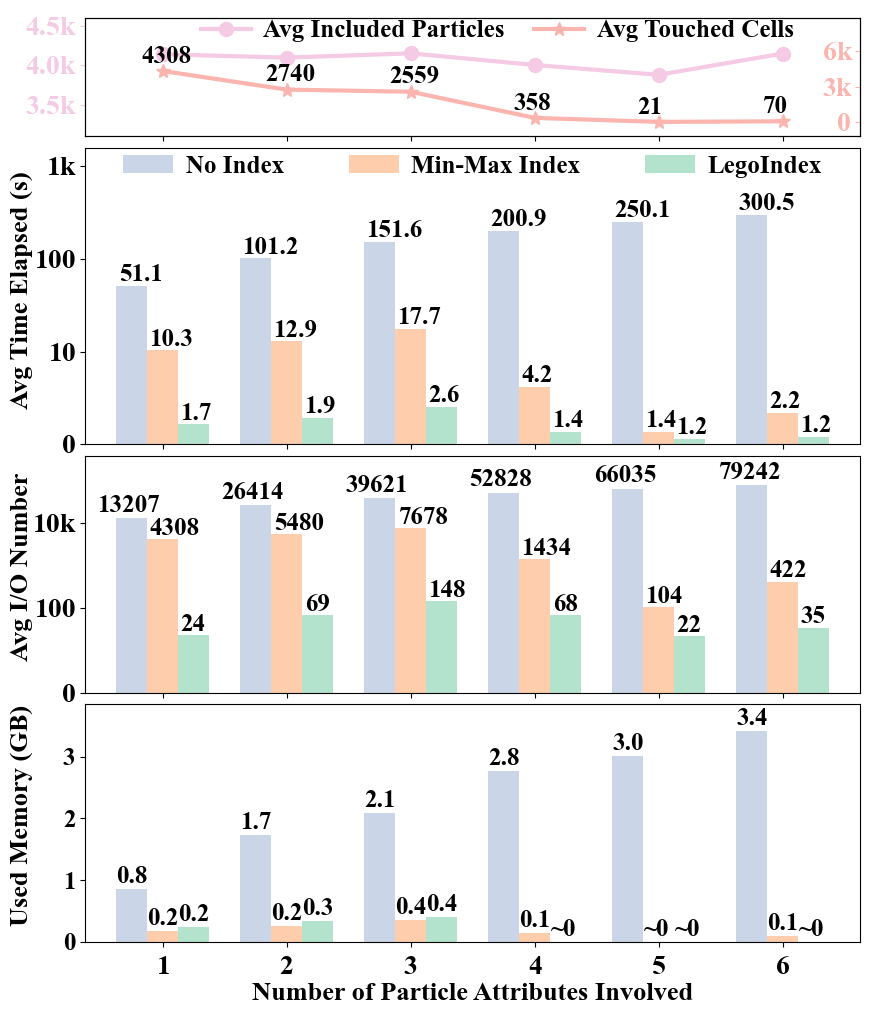

In [23]:
# only keep the test_type with specific values: 1 and 25\
plot_df = averaged_df[averaged_df['test_type'].isin([1, 2, 25])]

#

row_ratios = [2, 5, 4, 4]

# fig, ax = plt.subplots()
# set figure size
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 12), gridspec_kw={'height_ratios': row_ratios})

''' subplot 1 '''
ax = axes[0]
plot_df[averaged_df['test_type'] == 25].pivot(index='plot_from_0', columns='test_type', values='data_size').plot(kind='line', ax=ax, color='#f4cae4', marker='o', markersize=10, linewidth=3)
plt.xticks(rotation=0)
ax.set_ylim(3100, 4600)

# ax.yaxis.set_major_locator(MultipleLocator(1e4))
current_values = ax.get_yticks()
print(current_values)

ax.set_yticklabels([f"{round(y / 1000, 1)}k" if y != 0 else "0" for y in current_values])
# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#f4cae4')  # Adjust label size as needed

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Remove the legend
# ax.get_legend().remove()
legend = ax.legend(title='', loc='upper left', labels=['Avg Included Particles'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.12, 1.17), columnspacing=2.6, handletextpad=0.5)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))

# ax2.yaxis.set_tick_params(direction='in')  # Move ticks inside
ax2.yaxis.set_tick_params(direction='in', pad=-27)  # Move ticks inside
# ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()


plot_df[plot_df['test_type'] == 25].pivot(index='plot_from_0', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='#fbb4ae', marker='*', markersize=10, linewidth=3)

# Annotate each data point
for i, (x, y) in enumerate(zip(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata())):
    ax2.annotate(
        str(round(y)),  # Text label
        (x - 0.17, y + 700),  # Position (adjust y + 200 for visibility)
        fontsize=global_annotation_fontsize,
        fontweight='bold'
    )


# ax.set_autoscale_on(False)
ax2.set_ylim(-1200, 8800)

# y label
# ax.set_ylabel("Avg Touched Cells", fontsize=global_label_fontsize - 5, labelpad=25, fontweight='bold')
ax2.yaxis.set_label_coords(-0.068, 0.5)

ax2.yaxis.set_major_locator(MultipleLocator(3000))
current_values = ax2.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# ax2.set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in current_values])
y_ticks = ["-1", "  0", "3k", "6k"]
ax2.set_yticklabels(y_ticks)
ax2.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#fbb4ae')  # Adjust label size as needed


for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

legend = ax2.legend(title='', loc='upper left', labels=['Avg Touched Cells'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.55, 1.17), columnspacing=2.6, handletextpad=0.5)
for text in legend.get_texts():
    text.set_fontweight('bold')


''' subplot 2 '''
# the value difference between test_type 1 and 25 is too large, so we use log scale
plot_df['total_time_elapsed'] = plot_df['total_time_elapsed'].apply(lambda x: np.log10(x+1))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

ax = axes[1]
# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
# plot_df.pivot(index='select_set_length', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
plot_df.pivot(index='select_set_length', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#cbd5e8', '#fdcdac', '#b3e2cd'])
plt.xticks(rotation=0)
legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0.02, 1.05), columnspacing=2.6, handletextpad=0.5)
# legend = ax.legend(title='', loc='upper left', labels=['OpenPMD-viewer', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0, 1.13), columnspacing=0.8)

for text in legend.get_texts():
    text.set_fontweight('bold')

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x() + 0.02, p.get_height() + 0.05), fontsize=global_annotation_fontsize, fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 3.2)

# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.52)

current_values = ax.get_yticks()

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MultipleLocator(1))
y_ticks = ["-1", "0", "10", "100", "1k", "10k"]
# ax.set_yticklabels([str(int(pow(10, y*2))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
plt.subplots_adjust(hspace=0.05)


''' subplot 3 '''
ax = axes[2]
plot_df.loc[plot_df['test_type'] == 1, "grouping_io_number"] = 13207 * plot_df.loc[plot_df['test_type'] == 1, "select_set_length"]
plot_df['grouping_io_number'] = plot_df['grouping_io_number'].apply(lambda x: np.log10(x))
plot_df.pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='bar', ax=ax, width=0.75, color=['#cbd5e8', '#fdcdac', '#b3e2cd'])

for i, p in enumerate(ax.patches):
    if i < 6:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() - 0.15, p.get_height() + 0.15), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() + 0.02, p.get_height() + 0.10), fontsize=global_annotation_fontsize, fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 5.6)
# x label
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg I/O Number", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)

current_values = ax.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
y_ticks = ["0", "100", "10k"]
# ax.set_yticklabels([str(int(pow(10, y*2))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()

''' subplot 4 '''
ax = axes[3]
plot_df.pivot(index='select_set_length', columns='test_type', values='total_memory_used').plot(kind='bar', ax=ax, width=0.75, color=['#cbd5e8', '#fdcdac', '#b3e2cd'])
ax.tick_params(axis='x', rotation=0)

for i, p in enumerate(ax.patches):
    ax.annotate(str(round(p.get_height(), 1)) if p.get_height() > 0.01 else "~0", (p.get_x(), p.get_height() + 0.1), fontsize=global_annotation_fontsize , fontweight='bold')
    # if i == 0:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 60), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 6:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 40), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 9:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 110), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i > 11:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 30), fontsize=global_annotation_fontsize , fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 50), fontsize=global_annotation_fontsize , fontweight='bold')

ax.set_ylim(0, 3.85)
# x label
ax.yaxis.set_label_coords(-0.068, 0.53)
ax.yaxis.set_major_locator(MultipleLocator(1))

current_values = ax.get_yticks()
print(current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.set_yticklabels([str(int(y)) if y != 0 else "0" for y in current_values])
y_ticks = ["-500", "0", "1", "2", "3", "4"]
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)


ax.set_ylabel("Used Memory (GB)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize - 5, labelpad=2, fontweight='bold')
""""""
plt.savefig(proj_path + "plot/final/overall_query_time_comparison_small_v3.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
print()

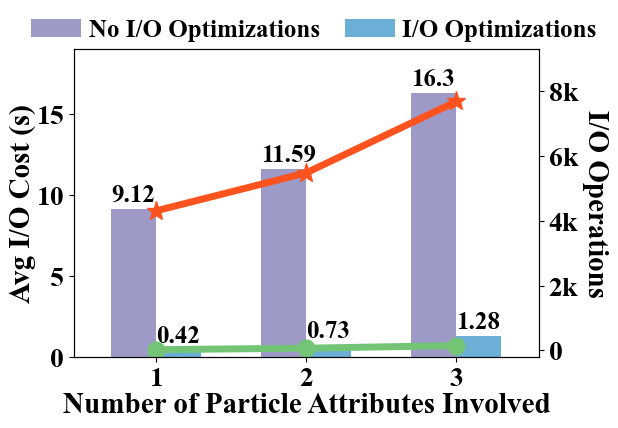

In [24]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([23, 25])]

plot_df = plot_df[plot_df['select_set_length'] <= 3]
# the value difference between test_type 1 and 25 is too large, so we use log scale
# plot_df['IO_time'] = plot_df['IO_time'].apply(lambda x: np.log10(x))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 4)


# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='IO_time').plot(kind='bar', ax=ax, width=0.6, color=['#9e9ac8', '#6baed6'])

# mark the number on the top of each bar before log
for p in ax.patches:
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x(), p.get_height() + 0.5), fontsize=global_annotation_fontsize, fontweight='bold')

legend = ax.legend(title='', loc='upper left', labels=['No I/O Optimizations', 'I/O Optimizations'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-.14, 1.17), columnspacing=1.0, handletextpad=0.3)
# legend = ax.legend(title='', loc='upper left', labels=['No I/O Grouping', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-.1, 1.15), columnspacing=1.6)

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 19)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize - 3, fontweight='bold', labelpad=1)
# y label
plt.ylabel("Avg I/O Cost (s)", fontsize=global_label_fontsize - 3, fontweight='bold', labelpad=0)

# current_values = plt.gca().get_yticks()
from matplotlib.ticker import MaxNLocator, MultipleLocator
plt.gca().yaxis.set_major_locator(MultipleLocator(5))
# plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)  # Adjust label size as needed

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='direct_io_number').plot(kind='line', ax=ax2, color='#ff531f', marker='*', markersize=14, linewidth=5)
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='line', ax=ax2, color='#74c476', marker='o', markersize=12, linewidth=5)


plt.ylim(-200, 9300)

# y label
plt.ylabel("I/O Operations", fontsize=global_label_fontsize -3 , rotation=270, fontweight='bold', labelpad=22)
current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(2000))
plt.gca().set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in plt.gca().get_yticks()])
# plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))
# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed

# Remove the legend
plt.gca().get_legend().remove()
plt.yticks(fontweight='bold')
plt.savefig(proj_path + "plot/final/io_grouping_comparison_small_v3.pdf", bbox_inches='tight', pad_inches=0.01)

plt.show()

print()

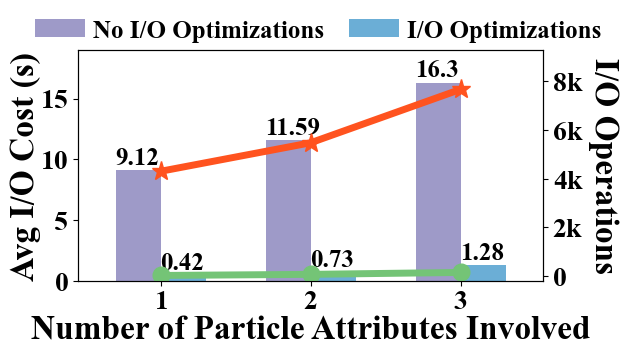

In [25]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([23, 25])]

plot_df = plot_df[plot_df['select_set_length'] <= 3]
# the value difference between test_type 1 and 25 is too large, so we use log scale
# plot_df['IO_time'] = plot_df['IO_time'].apply(lambda x: np.log10(x))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 3)


# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='IO_time').plot(kind='bar', ax=ax, width=0.6, color=['#9e9ac8', '#6baed6'])

# mark the number on the top of each bar before log
for p in ax.patches:
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x(), p.get_height() + 0.5), fontsize=global_annotation_fontsize, fontweight='bold')

legend = ax.legend(title='', loc='upper left', labels=['No I/O Optimizations', 'I/O Optimizations'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-.14, 1.23), columnspacing=1.0, handletextpad=0.3)
# legend = ax.legend(title='', loc='upper left', labels=['No I/O Grouping', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-.1, 1.15), columnspacing=1.6)

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 19)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, fontweight='bold', labelpad=1)
# y label
plt.ylabel("Avg I/O Cost (s)", fontsize=global_label_fontsize, fontweight='bold', labelpad=0)

# current_values = plt.gca().get_yticks()
from matplotlib.ticker import MaxNLocator, MultipleLocator
plt.gca().yaxis.set_major_locator(MultipleLocator(5))
# plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)  # Adjust label size as needed

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='direct_io_number').plot(kind='line', ax=ax2, color='#ff531f', marker='*', markersize=14, linewidth=5)
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='line', ax=ax2, color='#74c476', marker='o', markersize=12, linewidth=5)


plt.ylim(-200, 9300)

# y label
plt.ylabel("I/O Operations", fontsize=global_label_fontsize , rotation=270, fontweight='bold', labelpad=26)
current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(2000))
plt.gca().set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in plt.gca().get_yticks()])
# plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))
# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed

# Remove the legend
plt.gca().get_legend().remove()
plt.yticks(fontweight='bold')
plt.savefig(proj_path + "plot/final/io_grouping_comparison_small_v4.pdf", bbox_inches='tight', pad_inches=0.01)

plt.show()

print()

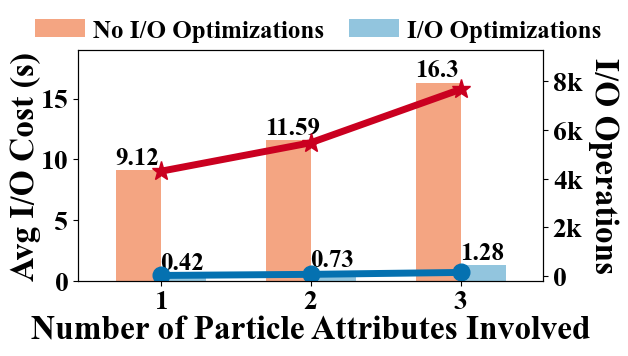

In [26]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([23, 25])]

plot_df = plot_df[plot_df['select_set_length'] <= 3]
# the value difference between test_type 1 and 25 is too large, so we use log scale
# plot_df['IO_time'] = plot_df['IO_time'].apply(lambda x: np.log10(x))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 3)


# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='IO_time').plot(kind='bar', ax=ax, width=0.6, color=['#f4a582', '#92c5de'])

# mark the number on the top of each bar before log
for p in ax.patches:
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x(), p.get_height() + 0.5), fontsize=global_annotation_fontsize, fontweight='bold')

legend = ax.legend(title='', loc='upper left', labels=['No I/O Optimizations', 'I/O Optimizations'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-.14, 1.23), columnspacing=1.0, handletextpad=0.3)
# legend = ax.legend(title='', loc='upper left', labels=['No I/O Grouping', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-.1, 1.15), columnspacing=1.6)

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 19)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, fontweight='bold', labelpad=1)
# y label
plt.ylabel("Avg I/O Cost (s)", fontsize=global_label_fontsize, fontweight='bold', labelpad=0)

# current_values = plt.gca().get_yticks()
from matplotlib.ticker import MaxNLocator, MultipleLocator
plt.gca().yaxis.set_major_locator(MultipleLocator(5))
# plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)  # Adjust label size as needed

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='direct_io_number').plot(kind='line', ax=ax2, color='#ca0020', marker='*', markersize=14, linewidth=5)
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='line', ax=ax2, color='#0571b0', marker='o', markersize=12, linewidth=5)


plt.ylim(-200, 9300)

# y label
plt.ylabel("I/O Operations", fontsize=global_label_fontsize , rotation=270, fontweight='bold', labelpad=26)
current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(2000))
plt.gca().set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in plt.gca().get_yticks()])
# plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))
# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed

# Remove the legend
plt.gca().get_legend().remove()
plt.yticks(fontweight='bold')
plt.savefig(proj_path + "plot/final/io_grouping_comparison_small_v5.pdf", bbox_inches='tight', pad_inches=0.01)

plt.show()

print()